# Playground for LLMs

GPT 5 api model

In [5]:
from src.llm import load_model

model = load_model(model_id="gpt-5.1", reasoning="high")

prompt = ["What is the capital of Italy?"]
answer = model.generate_batch(prompt)
print(answer[0][0])

[INFO] Initialized APILLM with model_id: gpt-5.1
[INFO] Reasoning parameters: {'effort': 'high'}
The capital of Italy is Rome.


Llama 3.2 1B Instruct model

In [ ]:
from src.llm import LocalLLM

model = LocalLLM(model_id="meta-llama/Llama-3.2-1B-Instruct")

prompt = ["What is the capital of Italy?"]
response = model.generate_batch(prompt)

print(response[0][0])

Llama 3.2 70B Chat model with 8-bit quantization

In [ ]:
from src.llm import LocalLLM

model = LocalLLM(model_id="meta-llama/Llama-2-70b-chat-hf")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

In [ ]:
from src.llm import LocalLLM

model = LocalLLM(model_id="google/gemma-3-4b-it")

prompt = ["What is the capital of Israel?"]
response = model.generate_batch(prompt)

print(response[0][0])

In [ ]:
import json
import random

with open("./llms.json", "r") as f:
    available_llms = json.load(f)["llms"]

llms = random.sample(available_llms, 2)
names = [llm["name"] for llm in available_llms]
shortnames = [llm["shortname"] for llm in available_llms]

print(names)
print(shortnames)

In [ ]:
available_llms

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Per-topic overall agreement (0–1), from your provided analysis
amsterdam = {
    "Materials & Gemstones": 0.83,
    "Colors": 0.67,
    "Transportation": 0.67,
    "Animals": 0.67,
    "Food & Drink": 0.33,
    "Geography": 0.33,
    "Car brands": 0.33,
    "Activities & Sports": 0.50,
}

nottingham = {
    "Astronomy/Planets": 1.00,
    "Car brands": 1.00,
    "Rewards/Prizes": 1.00,
    "Food & Drink": 0.83,
    "Geography": 0.83,
    "Time & Dates": 0.83,
    "Furniture": 0.67,
    "Colors": 0.00,
    "Numbers": 0.00,
    "Activities & Sports": 0.00,
    "People/Names": 0.33,
}


def plot_topic_agreement(data, title, savepath=None, thresholds=(0.67, 0.5)):
    topics, vals = zip(*sorted(data.items(), key=lambda kv: kv[1], reverse=True))
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(len(topics)), vals, color="steelblue")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels(topics, rotation=45, ha="right")
    ax.set_ylabel("Agreement (0–1)")
    ax.set_title(title)
    # Threshold lines for quick reference
    for y, c in zip(thresholds, ["green", "orange"]):
        ax.axhline(y, color=c, linestyle="--", linewidth=1, alpha=0.6)
    # Annotate values
    for bar, val in zip(bars, vals):
        ax.annotate(
            f"{val:.2f}",
            (bar.get_x() + bar.get_width() / 2, val),
            ha="center",
            va="bottom",
            fontsize=8,
        )
    fig.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    return fig, ax


def plot_common(amsterdam, nottingham, title, savepath=None, thresholds=(0.67, 0.5)):
    topics = sorted(set(amsterdam) & set(nottingham))
    a_vals = [amsterdam[t] for t in topics]
    n_vals = [nottingham[t] for t in topics]
    x = np.arange(len(topics))
    w = 0.38

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w / 2, a_vals, width=w, label="Amsterdam", color="tab:blue")
    ax.bar(x + w / 2, n_vals, width=w, label="Nottingham", color="tab:orange")

    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(topics, rotation=45, ha="right")
    ax.set_ylabel("Agreement (0–1)")
    ax.set_title(title)
    ax.legend()

    # Threshold lines
    for y, c in zip(thresholds, ["green", "orange"]):
        ax.axhline(y, color=c, linestyle="--", linewidth=1, alpha=0.6)

    # Annotate values
    for i, val in enumerate(a_vals):
        ax.annotate(
            f"{val:.2f}", (x[i] - w / 2, val), ha="center", va="bottom", fontsize=8
        )
    for i, val in enumerate(n_vals):
        ax.annotate(
            f"{val:.2f}", (x[i] + w / 2, val), ha="center", va="bottom", fontsize=8
        )

    fig.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200)
    return fig, ax


if __name__ == "__main__":
    # 1) Amsterdam topics
    plot_topic_agreement(
        amsterdam,
        title="Agreement by Topic — Amsterdam",
        savepath="agreement_amsterdam.png",
    )

    # 2) Nottingham topics
    plot_topic_agreement(
        nottingham,
        title="Agreement by Topic — Nottingham",
        savepath="agreement_nottingham.png",
    )

    # 3) Common topics
    plot_common(
        amsterdam,
        nottingham,
        title="Agreement by Topic — Common Topics",
        savepath="agreement_common.png",
    )

    plt.show()

In [56]:

# List all the files in a folder
import os
import random
from typing import List, Tuple

def split_into_blocks(csv_path):
    blocks = []
    current_block = []

    with open(csv_path, "r", encoding="utf-8") as f:
        for line in f:
            # Strip newline but keep commas structure
            stripped = line.rstrip("\n")
            if not stripped.strip(): 
                # Skip completely empty lines
                continue

            # Try to detect the start of a new block
            parts = stripped.split(",")
            first_cell = parts[0].strip()

            # A block starts when first cell is an integer game number (1,2,...)
            if first_cell.isdigit():
                # If there is an existing block, save it
                if current_block:
                    blocks.append(current_block)
                current_block = [stripped]  # Start new block
            else:
                # Inside a block → append line
                if current_block is not None:
                    current_block.append(stripped)

        # Append last block if exists
        if current_block:
            blocks.append(current_block)

    return blocks
        
def parse_line(line):
    parts = line.split(",")
    value = int(parts[9].strip())
    assigment = parts[10].strip()
    return value, assigment

def compute_value(assignments_player1:List[Tuple[int, str]], assignments_player2:List[Tuple[int, str]]) -> Tuple[float, float]:
    assert len(assignments_player1) == len(assignments_player2)
    v_player1, v_player2 = 0.0, 0.0
    for a1, a2 in zip(assignments_player1, assignments_player2):
        if a1[1] != a2[1]:
            v_player1 -= 0.2 * a1[0]
            v_player2 -= 0.2 * a1[0]
        elif a1[1] == a2[1] and a1[1] == "r1":
            v_player1 += a1[0]
        elif a1[1] == a2[1] and a1[1] == "r2":
            v_player2 += a1[0]

    return (v_player1, v_player2)

def signature(csv_file):
    blocks = split_into_blocks(csv_file)[1:]
    signature = ""
    for b in blocks:
        for row in b[3:]:
            row_split = row.split(',')
            x, y = row_split[-4], row_split[-3]
            signature += f"{x},{y};"
    return signature

folder_path = "./data/Dor-humans/bargaining-table/"
files = os.listdir(folder_path)

# Filter files with only results
PlayerNmber1_files, PlayerNmber2_files = [], []
for f in files:
    if "BT" in f:
        if "PlayerNmber1" in f:
            PlayerNmber1_files.append(f)
        if "PlayerNmber2" in f:
            PlayerNmber2_files.append(f)

game_num = 2
num_samples = 100
count = 0
player1_payoff, player2_payoff = 0.0, 0.0
for f1 in PlayerNmber1_files:
    sign_f1 = signature(os.path.join(folder_path, f1))
    sign_f2 = ""
    PlayerNmber2_files_copy = PlayerNmber2_files.copy()
    for f2 in PlayerNmber2_files_copy:
        sign_f2 = signature(os.path.join(folder_path, f2))
        if sign_f1 != sign_f2:
            continue
        
        blocks1 = split_into_blocks(os.path.join(folder_path, f1))[game_num][3:]
        blocks2 = split_into_blocks(os.path.join(folder_path, f2))[game_num][3:]
        
        # print(os.path.join(folder_path, f1))
        # print(os.path.join(folder_path, f2))
        
        for r1,r2 in zip(blocks1, blocks2):
            r1_v = r1.split(',')
            r2_v = r2.split(',')
            r1_t = r1_v[-1].strip()
            r2_t = r2_v[-1].strip()
            if r1_t == r2_t and r1_t == "r1":
                player1_payoff += int(r1_v[-2].strip())
            elif r1_t == r2_t and r1_t == "r2":
                player2_payoff += int(r2_v[-2].strip())
            else:
                player1_payoff -= 0.2 * int(r1_v[-2].strip())
                player2_payoff -= 0.2 * int(r2_v[-2].strip())
                
        count += 1



In [57]:
print(player1_payoff / count)
print(player2_payoff / count)
print(count)

2.6744840525327636
3.0281425891181333
2132


In [22]:
import json 
import re
from typing import List, Tuple

def extract_assignments(response: str) -> dict[List[List[int]], List[str]]:
    blue_str = ("b", "r1")  # Blue
    yellow_str = ("y", "r2")  # Yellow
    results = {}
    for ic, c in enumerate(response.lower()):
        if c == yellow_str[0]:
            x, y = int(response[ic-2]), int(response[ic-1])
            results[f"{x},{y}"] = yellow_str[1]
        elif c == blue_str[0]:
            x, y = int(response[ic-2]), int(response[ic-1])
            results[f"{x},{y}"] = blue_str[1]

    return results

with open("./data/Dor-humans/gpt-oss-120b/bargaining_table-vanilla_responses_problem.jsonl", "r") as f:
    data = json.load(f)

answer_reg = re.compile(r"<answer>(.*?)</answer>", re.DOTALL)    
for i in range(10):
    print(len(data[i]["responses"]))
    count = 0
    for r in data[i]["responses"]:
        match = answer_reg.search(r)
        if match:
            count += 1
            # Match the last answer tag
            answer = match.group(1).strip()
            print(extract_assignments(answer))
            alakazam
            # print(match.group(1))
    print(f"Total answers found in response {i}: {count}")

30
{'1,6': 'r2', '1,7': 'r2', '4,4': 'r1', '8,1': 'r1', '9,7': 'r2'}


NameError: name 'alakazam' is not defined

In [ ]:
import re
from typing import Dict, Tuple, List

def _to_cell(value: float, vmin: float, vmax: float) -> int:
    """Map a scalar to 1..9 using min-max; clamp edges to avoid 10 on vmax."""
    if vmax <= vmin:
        return 5  # degenerate: stick it in the middle row/col
    idx = int((value - vmin) / (vmax - vmin) * 9) + 1
    return max(1, min(9, idx))

def parse_game_block(raw: str):
    """
    Extract r1, r2 positions and discs (name, x, y, value, owner) from your CSV-ish block.
    Accepts variable commas/spaces exactly like your examples.
    """
    # Players: ... r1, , X, Y ...  and  ... r2, , X, Y ...
    r1_match = re.search(r'\br1\b(?:\s*,\s*)+\s*(\d+)\s*,\s*(\d+)', raw)
    r2_match = re.search(r'\br2\b(?:\s*,\s*)+\s*(\d+)\s*,\s*(\d+)', raw)
    if not (r1_match and r2_match):
        raise ValueError("Could not find r1/r2 coordinates.")

    r1_xy = (float(r1_match.group(1)), float(r1_match.group(2)))
    r2_xy = (float(r2_match.group(1)), float(r2_match.group(2)))

    # Discs: ... dK, X, Y, VALUE, OWNER ...
    discs = []
    for name, x, y, val, owner in re.findall(r'\b(d\d+)\b\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(r1|r2)', raw):
        discs.append({
            "name": name,
            "x": float(x),
            "y": float(y),
            "value": int(val),
            "owner": owner
        })

    return {"r1": r1_xy, "r2": r2_xy, "discs": discs}

def map_to_grid(game: Dict) -> Dict:
    """
    Min–max normalize X and Y across this game, then bin into 9×9.
    Y increases downward; row 1 is the minimum Y.
    """
    xs = [game["r1"][0], game["r2"][0]] + [d["x"] for d in game["discs"]]
    ys = [game["r1"][1], game["r2"][1]] + [d["y"] for d in game["discs"]]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    def to_rowcol(x, y):
        col = _to_cell(x, xmin, xmax)   # left → right
        row = _to_cell(y, ymin, ymax)   # top → bottom (row 1 at min Y)
        return (row, col)

    r1_rc = to_rowcol(*game["r1"])
    r2_rc = to_rowcol(*game["r2"])
    discs = [{"name": d["name"], "value": d["value"], "owner": d["owner"],
              "rowcol": to_rowcol(d["x"], d["y"])} for d in game["discs"]]

    return {"r1": r1_rc, "r2": r2_rc, "discs": discs}

def to_prompt(mapped: Dict) -> str:
    """Render the exact sentence structure you want."""
    r1_row, r1_col = mapped["r1"]
    r2_row, r2_col = mapped["r2"]

    parts = []
    parts.append("The coordinates are written as (row, column) on a 9x9 grid, where row 1 is the top row and column 1 is the leftmost column. You will have to play that game in the following state: "
                 f"You are the Blue player, and your square is located at ({r1_row}, {r1_col}). "
                 f"The other player's square (Yellow) is located at ({r2_row}, {r2_col}) ")

    discs = mapped["discs"]
    parts.append(f"There {'is' if len(discs)==1 else 'are'} {len(discs)} disc{'s' if len(discs)!=1 else ''} on the board: ")

    # Keep original CSV order
    descs = [f"a value-{d['value']} disc at ({d['rowcol'][0]}, {d['rowcol'][1]})" for d in discs]
    parts.append(", ".join(descs) + ".")

    return "".join(parts)

# --- Example usage ---
# raw = \"\"\" , , , , , ,r1, ,282,435
#              , , , , , ,r2, ,1213,435
#              , , , , , , ,d1,248,250,1,r1
#              , , , , , , ,d2,1019,250,2,r1
#              , , , , , , ,d3,1019,610,2,r2
#              , , , , , , ,d4,1333,610,3,r2 \"\"\"
# game = parse_game_block(raw)
# mapped = map_to_grid(game)
# print(to_prompt(mapped))

SyntaxError: unexpected character after line continuation character (771580688.py, line 80)

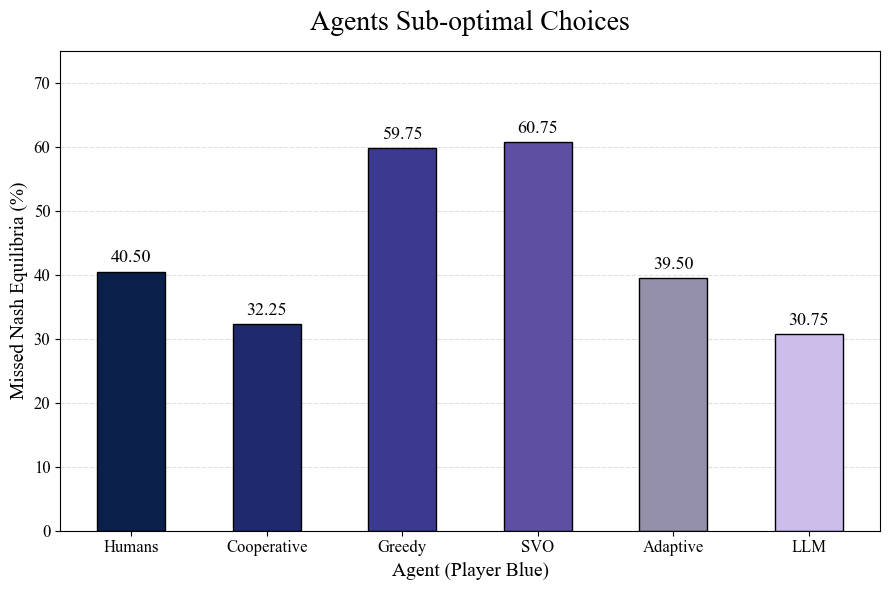

In [28]:
import matplotlib.pyplot as plt

# Data
labels = ["Humans", "Cooperative", "Greedy", "SVO", "Adaptive", "LLM"]
values = [40.5, 32.25, 59.75, 60.75, 39.5, 30.75]

# Global font settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 20,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

colors = [
    "#0B1F4B",  # Deep navy (anchor, Humans)
    "#1E2A6D",  # Royal indigo (Cooperative)
    "#3B3A8F",  # Muted violet-blue (Greedy)
    "#5E4FA2",  # Soft purple (SVO)
    "#9490AA",  # Soft purple (Adaptive)
    "#CDBDEB"   # Light lavender (LLM)
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

# Bar plot
bars = ax.bar(labels, 
              values, 
              edgecolor = "black",
              color=colors,
              width=0.5)

# Title and labels
ax.set_title("Agents Sub-optimal Choices", pad=15)
ax.set_ylabel("Missed Nash Equilibria (%)")
ax.set_xlabel("Agent (Player Blue)")

# Subtle horizontal grid
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Value annotations
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=13
    )

# Tight layout for clean spacing
plt.ylim(0, 75)
plt.tight_layout()
plt.show()


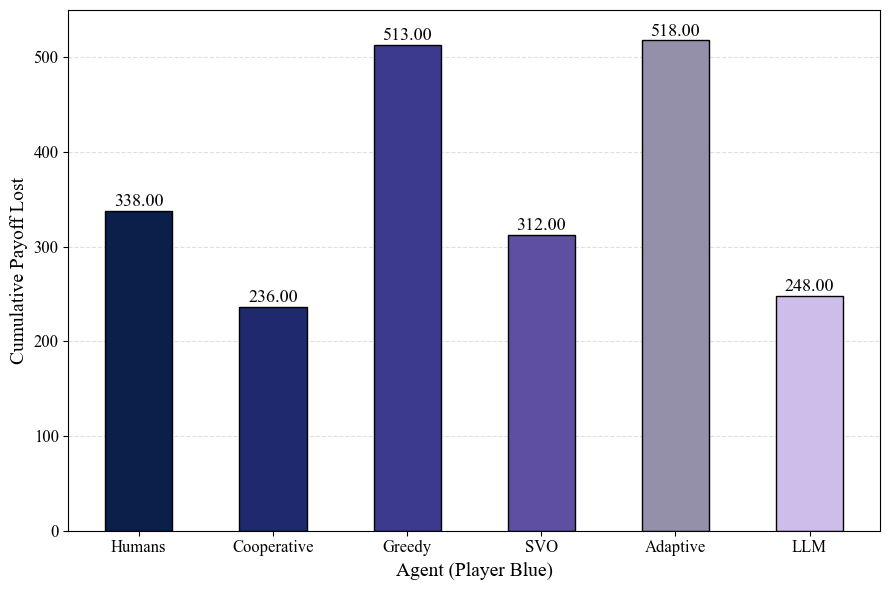

In [29]:
import matplotlib.pyplot as plt

# Data
labels = ["Humans", "Cooperative", "Greedy", "SVO", "Adaptive", "LLM"]
values = [338, 236, 513, 312, 518, 248]

# Global font settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 20,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

colors = [
    "#0B1F4B",  # Deep navy (anchor, Humans)
    "#1E2A6D",  # Royal indigo (Cooperative)
    "#3B3A8F",  # Muted violet-blue (Greedy)
    "#5E4FA2",  # Soft purple (SVO)
    "#9490AA",  # Soft purple (Adaptive)
    "#CDBDEB"   # Light lavender (LLM)
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

# Bar plot
bars = ax.bar(labels, 
              values, 
              edgecolor = "black",
              color=colors,
              width=0.5)

# Title and labels
# ax.set_title("Agents Sub-optimal Choices", pad=15)
ax.set_ylabel("Cumulative Payoff Lost")
ax.set_xlabel("Agent (Player Blue)")

# Subtle horizontal grid
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Value annotations
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=13
    )

# Tight layout for clean spacing
plt.ylim(0, 550)
plt.tight_layout()
plt.show()
